## Análise de Transferências de Jogadores

Este notebook tem como objetivo construir um modelo para avaliar o "fit" de um jogador a um clube, com base no histórico de transferências do clube. Utilizaremos dados de transferências de futebol para analisar padrões e criar um sistema de recomendação.

### 1. Importação e Carregamento dos Dados

Esta seção se concentra em carregar os conjuntos de dados iniciais (`transfers.csv`, `players.csv`, `clubs.csv`) de uma fonte externa (Kagglehub) e realizar uma inspeção inicial para entender sua estrutura e conteúdo.

Importações dos dados


In [1]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("davidcariboo/player-scores/versions/652")  # pin: versões mais novas do dataset vêm com bem menos transferências
print("Path to dataset files:", path)

# Carregar as três tabelas necessárias
transfers = pd.read_csv(f"{path}/transfers.csv")
players = pd.read_csv(f"{path}/players.csv")
clubs = pd.read_csv(f"{path}/clubs.csv")

print("\n--- transfers.csv ---")
print(transfers.shape)
print(transfers.columns.tolist())
print(transfers.head(2))

print("\n--- players.csv ---")
print(players.shape)
print(players.columns.tolist())
print(players.head(2))

print("\n--- clubs.csv ---")
print(clubs.shape)
print(clubs.columns.tolist())
print(clubs.head(2))


/Users/rodri/Desktop/Career-Hub/API/fit-score-svc/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/rodri/.cache/kagglehub/datasets/davidcariboo/player-scores/versions/652

--- transfers.csv ---
(157186, 10)
['player_id', 'transfer_date', 'transfer_season', 'from_club_id', 'to_club_id', 'from_club_name', 'to_club_name', 'transfer_fee', 'market_value_in_eur', 'player_name']
   player_id transfer_date transfer_season  from_club_id  to_club_id  \
0     467994    2030-06-30           25/26          5621         749   
1     784335    2027-07-18           27/28          6505        6502   

    from_club_name     to_club_name  transfer_fee  market_value_in_eur  \
0         Reggiana        FC Empoli           0.0             700000.0   
1  Gimcheon Sangmu  Jeonbuk Hyundai           0.0             500000.0   

         player_name  
0  Luca Belardinelli  
1      Jun-soo Byeon  

--- players.csv ---
(47702, 26)
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citiz

### 2. Engenharia de Features e Limpeza Inicial

Nesta etapa, calculamos a idade dos jogadores no momento da transferência e realizamos junções entre as tabelas de `transfers` e `players` para enriquecer o dataframe principal (`df`). Também é adicionada a liga de origem (`origin_league`) do clube vendedor. Realizamos uma análise de valores nulos para entender a cobertura dos dados, especialmente para o `origin_league` e `transfer_fee`.

In [2]:

# Calcular idade no momento da transferência
transfers['transfer_date'] = pd.to_datetime(transfers['transfer_date'], errors='coerce')
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'], errors='coerce')

# Join transfers + players
df = transfers.merge(
    players[['player_id', 'country_of_citizenship', 'position', 'sub_position', 'date_of_birth']],
    on='player_id',
    how='left'
)

df['age_at_transfer'] = (
    (df['transfer_date'] - df['date_of_birth']).dt.days / 365.25
).round(1)

# Join com clubs para liga de origem
df = df.merge(
    clubs[['club_id', 'domestic_competition_id']].rename(columns={
        'club_id': 'from_club_id',
        'domestic_competition_id': 'origin_league'
    }),
    on='from_club_id',
    how='left'
)

# --- Detecção de retorno de empréstimo (loan return) ---
# Uma ENTRADA (to_club) é retorno de empréstimo quando: (a) o mesmo player_id já teve uma
# SAÍDA anterior desse mesmo clube (from_club == to_club, em data anterior) E (b) a entrada
# é gratuita (transfer_fee 0/NaN). A condição (b) preserva RECOMPRAS reais pagas (ex: Pogba
# voltando da Juventus por fee alto) — só remove o vai-e-volta de empréstimo sem custo.
df = df.sort_values('transfer_date').reset_index(drop=True)

# Primeira data em que cada (player, clube) aparece como ORIGEM (= jogador saiu desse clube)
_left = df.assign(_k=df['player_id'].astype(str) + '|' + df['from_club_id'].astype(str))
_first_exit = _left.groupby('_k')['transfer_date'].min()

_entry_k = df['player_id'].astype(str) + '|' + df['to_club_id'].astype(str)
_exit_date = _entry_k.map(_first_exit)            # quando (se) o jogador saiu desse clube de destino
_returned = _exit_date.notna() & (_exit_date < df['transfer_date'])
_free = df['transfer_fee'].isna() | (df['transfer_fee'] == 0)
df['is_loan_return'] = _returned & _free

print("Retornos de empréstimo detectados (fee≈0):", int(df['is_loan_return'].sum()))
# Validação Man United CM — antes do filtro
_mu = df[(df['to_club_name'] == 'Man Utd')]
print("Man Utd — entradas marcadas como loan return:")
print(_mu[_mu['is_loan_return']][['transfer_season','player_name','from_club_name','transfer_fee']].to_string(index=False))

# Checar cobertura — transfer_fee não é obrigatório (free transfer é válido)
print("Total transferências:", len(df))
print("\nNulos por coluna relevante (exceto fee):")
print(df[['country_of_citizenship', 'position', 'age_at_transfer', 'origin_league']].isnull().sum())

print("\n% de transferências com dados completos (sem contar fee):", round(
    df[['country_of_citizenship', 'position', 'age_at_transfer', 'origin_league']].notna().all(axis=1).mean() * 100, 1
), "%")

print("\n% de transferências sem liga de origem:", round(df['origin_league'].isnull().mean() * 100, 1), "%")

# Fee: informativo apenas
print("\n--- Fee (informativo) ---")
print("Com fee declarado (> 0):", (df['transfer_fee'] > 0).sum())
print("Free transfer (fee = 0):", (df['transfer_fee'] == 0).sum())
print("Fee não divulgado (null):", df['transfer_fee'].isnull().sum())

print("\nLigas de origem mais comuns:")
print(df['origin_league'].value_counts().head(15))


Retornos de empréstimo detectados (fee≈0): 33968
Man Utd — entradas marcadas como loan return:
transfer_season               player_name  from_club_name  transfer_fee
          05/06                Tom Heaton    Swindon Town           0.0
          05/06                Tom Heaton   Royal Antwerp           0.0
          06/07               Jonny Evans   Royal Antwerp           0.0
          06/07               Jonny Evans      Sunderland           0.0
          07/08               Jonny Evans      Sunderland           0.0
          08/09                Tom Heaton         Cardiff           0.0
          09/10                Tom Heaton             QPR           0.0
          09/10                Tom Heaton        Rochdale           0.0
          09/10             Danny Welbeck         Preston           0.0
          09/10                Tom Heaton         Wycombe           0.0
          09/10               Zoran Tosic       1.FC Köln           0.0
          10/11           Ritchie De Laet

### 3. Exploração de Dados Adicionais e Cobertura

Esta seção explora outros arquivos disponíveis no dataset para verificar se há dados adicionais que possam complementar a informação da liga de origem. Além disso, avaliamos a cobertura dos dados para os clubes de destino e, especificamente, para os 50 clubes mais relevantes em termos de volume de transferências, a fim de entender a qualidade dos dados para a análise principal.

In [3]:
import os

# 1. Ver todos os arquivos disponíveis no dataset — pode ter mais tabelas úteis
print("Arquivos no dataset:")
for f in sorted(os.listdir(path)):
    size = os.path.getsize(f"{path}/{f}") / 1024
    print(f"  {f} ({size:.0f} KB)")

# 2. Checar cobertura dos clubes de DESTINO (to_club_id)
# o modelo é sobre o perfil do clube que contrata — não de onde vem
clubs_in_transfers = df['to_club_id'].nunique()
clubs_with_league = df[df['origin_league'].notna()]['to_club_id'].nunique()

print(f"\nClubes de destino únicos no dataset: {clubs_in_transfers}")
print(f"Que aparecem em pelo menos 1 transferência com liga de origem: {clubs_with_league}")

# 3. Para os clubes mais relevantes (top 50), qual é a cobertura?
top_clubs = df['to_club_name'].value_counts().head(50).index
df_top = df[df['to_club_name'].isin(top_clubs)]
coverage_top = df_top['origin_league'].notna().mean()
print(f"\nCobertura de origin_league nos top 50 clubes: {round(coverage_top * 100, 1)}%")


Arquivos no dataset:
  appearances.csv (143129 KB)
  club_games.csv (10541 KB)
  clubs.csv (180 KB)
  competitions.csv (11 KB)
  countries.csv (12 KB)
  game_events.csv (149325 KB)
  game_lineups.csv (330077 KB)
  games.csv (25097 KB)
  national_teams.csv (25 KB)
  player_valuations.csv (29319 KB)
  players.csv (16335 KB)
  transfers.csv (13029 KB)

Clubes de destino únicos no dataset: 11521
Que aparecem em pelo menos 1 transferência com liga de origem: 3574

Cobertura de origin_league nos top 50 clubes: 68.5%


### 4. Mapeamento Refinado de Ligas Domésticas

Para melhorar a cobertura da `origin_league`, que estava baixa na etapa inicial, carregamos as tabelas `competitions.csv` e `club_games.csv`. A intenção é usar o histórico de jogos dos clubes para identificar suas ligas domésticas mais frequentes e, assim, criar um mapeamento mais robusto. Essa abordagem visa preencher os valores ausentes de `origin_league` de forma mais precisa.

In [4]:
competitions = pd.read_csv(f"{path}/competitions.csv")
club_games = pd.read_csv(f"{path}/club_games.csv")

print("--- competitions.csv ---")
print(competitions.columns.tolist())
print(competitions.head(3))

print("\n--- club_games.csv ---")
print(club_games.columns.tolist())
print(club_games.head(3))

# Se club_games tiver club_id + competition_id, podemos montar um mapeamento muito mais completo
if 'club_id' in club_games.columns and 'competition_id' in club_games.columns:
    club_league_map = (
        club_games.groupby('club_id')['competition_id']
        .agg(lambda x: x.mode()[0])  # liga mais frequente por clube
        .reset_index()
        .rename(columns={'competition_id': 'domestic_competition_id'})
    )
    print(f"\nClubes mapeados via club_games: {len(club_league_map)}")
    print(club_league_map.head(5))


--- competitions.csv ---
['competition_id', 'competition_code', 'name', 'sub_type', 'type', 'country_id', 'country_name', 'domestic_league_code', 'confederation', 'total_clubs', 'url']
  competition_id       competition_code                   name  \
0             A1             bundesliga             bundesliga   
1           AFAC          afc-asian-cup          afc-asian-cup   
2           AFCN  africa-cup-of-nations  africa-cup-of-nations   

                sub_type                       type  country_id country_name  \
0             first_tier            domestic_league         127      Austria   
1          afc_asian_cup  national_team_competition          -1          NaN   
2  africa_cup_of_nations  national_team_competition          -1          NaN   

  domestic_league_code confederation  total_clubs  \
0                   A1        europa         12.0   
1                  NaN         asien          NaN   
2                  NaN        afrika          NaN   

                

### 5. Consolidação do Mapeamento de Ligas

Com base nas tabelas `games.csv`, `club_games.csv` e `competitions.csv`, esta etapa constrói um mapeamento abrangente de `club_id` para `domestic_league_code`. O objetivo é identificar a liga doméstica mais frequente para cada clube, filtrando as competições por tipo `domestic_league`, para garantir que apenas ligas nacionais sejam consideradas. Por fim, avaliamos o impacto desse novo mapeamento na cobertura total da `origin_league` no dataframe de transferências.

In [5]:
games = pd.read_csv(f"{path}/games.csv")

print("--- games.csv ---")
print(games.columns.tolist())
print(games.head(2))

# Se games tiver game_id + competition_id, montamos o mapeamento completo
if 'competition_id' in games.columns:
    # club_id → game_id → competition_id → liga doméstica
    club_competition = (
        club_games[['club_id', 'game_id']]
        .merge(games[['game_id', 'competition_id']], on='game_id')
        .merge(
            competitions[competitions['type'] == 'domestic_league'][['competition_id', 'domestic_league_code']],
            on='competition_id'
        )
    )

    # Pegar a liga doméstica mais frequente por clube (evita copas internacionais distorcerem)
    club_league_expanded = (
        club_competition.groupby('club_id')['domestic_league_code']
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={'domestic_league_code': 'origin_league'})
    )

    print(f"\nClubes mapeados via games: {len(club_league_expanded)}")

    # Testar impacto no df original
    df_test = transfers.merge(
        club_league_expanded.rename(columns={'club_id': 'from_club_id'}),
        on='from_club_id',
        how='left'
    )
    print(f"Nova cobertura de origin_league: {round(df_test['origin_league'].notna().mean() * 100, 1)}%")


--- games.csv ---
['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'home_club_position', 'away_club_position', 'home_club_manager_name', 'away_club_manager_name', 'stadium', 'attendance', 'referee', 'url', 'home_club_formation', 'away_club_formation', 'home_club_name', 'away_club_name', 'aggregate', 'competition_type']
   game_id competition_id  season        round        date  home_club_id  \
0  1026846           FIWC    2009  Round of 16  2010-06-26          3449   
1  1026847           FIWC    2009  Round of 16  2010-06-27          3437   

   away_club_id  home_club_goals  away_club_goals  home_club_position  ...  \
0          3589                2                1                 NaN  ...   
1          6303                3                1                 NaN  ...   

                      stadium attendance          referee  \
0  Nelson Mandela Bay Stadium    30597.0   Wolfgang Stark   
1              

### 6. Limpeza e Preparação do Dataset Final

Nesta fase, criamos o dataset `df_clean` filtrando as transferências que possuem informações completas para `origin_league` e `age_at_transfer`, pois estas são as features essenciais para o modelo. Em seguida, realizamos uma análise descritiva desse dataset, verificando o número de transferências, clubes e ligas únicas, e o período coberto. Também identificamos os clubes com maior volume de transferências.

In [6]:
df_clean = df[
    df['origin_league'].notna() &
    df['age_at_transfer'].notna() &
    ~df['is_loan_return']
].copy()

print("Dataset de trabalho:", len(df_clean), "transferências")
print("Clubes de destino únicos:", df_clean['to_club_name'].nunique())
print("Ligas de origem únicas:", df_clean['origin_league'].nunique())
print("Período coberto:", df_clean['transfer_date'].min(), "→", df_clean['transfer_date'].max())

club_counts = df_clean.groupby('to_club_name').size().sort_values(ascending=False)
print("\nClubes com 10+ transferências:", (club_counts >= 10).sum())
print("\nTop 20 clubes por volume:")
print(club_counts.head(20))


Dataset de trabalho: 43717 transferências
Clubes de destino únicos: 3453
Ligas de origem únicas: 32
Período coberto: 2001-01-01 00:00:00 → 2027-07-04 00:00:00

Clubes com 10+ transferências: 1022

Top 20 clubes por volume:
to_club_name
Without Club     1335
Hellas Verona     146
Genoa             144
Olympiacos        129
Fiorentina        120
Marseille         120
Roma              117
Torino            116
Inter             112
Benfica           108
Retired           108
Sevilla FC        108
AC Milan          106
Fenerbahçe        105
Galatasaray       104
Nott'm Forest     104
Besiktas          104
Sassuolo          102
FC Empoli          99
Sampdoria          99
dtype: int64


### 7. Análise Exploratória de Features Principais

Esta seção realiza uma análise aprofundada da distribuição de algumas das features mais importantes para o modelo: `position` (posição do jogador), `age_at_transfer` (idade na transferência) e `transfer_fee` (valor da transferência). Para o `transfer_fee`, categorizamos as transferências em 'paid', 'free' e 'undisclosed' para uma melhor compreensão e análise de suas distribuições.

In [7]:
# Distribuição de posições
print("Distribuição por posição:")
print(df_clean['position'].value_counts())

# Distribuição de idade
print("\nIdade na transferência:")
print(df_clean['age_at_transfer'].describe())

# Fee: distribuição das categorias
df_clean['fee_type'] = df_clean['transfer_fee'].apply(
    lambda x: 'paid' if pd.notna(x) and x > 0 else ('free' if pd.notna(x) else 'undisclosed')
)
print("\nTipo de transferência:")
print(df_clean['fee_type'].value_counts())

# Distribuição de fee nas pagas
paid = df_clean[df_clean['fee_type'] == 'paid']['transfer_fee']
print("\nFee (transferências pagas) em EUR:")
print(paid.describe())


Distribuição por posição:
position
Defender      13676
Attack        13349
Midfield      12005
Goalkeeper     4676
Missing          11
Name: count, dtype: int64

Idade na transferência:
count    43717.000000
mean        24.485351
std          3.932160
min         14.800000
25%         21.500000
50%         23.900000
75%         26.900000
max         43.300000
Name: age_at_transfer, dtype: float64

Tipo de transferência:
fee_type
free           26617
paid           12286
undisclosed     4814
Name: count, dtype: int64

Fee (transferências pagas) em EUR:
count    1.228600e+04
mean     6.282827e+06
std      1.131587e+07
min      5.000000e+02
25%      7.270000e+05
50%      2.300000e+06
75%      6.842500e+06
max      2.220000e+08
Name: transfer_fee, dtype: float64


### 8. Refinamento de Features e Correlações

Continuamos o processo de limpeza, removendo entradas com `position` 'Missing'. Para o `transfer_fee`, que possui muitos valores nulos, utilizamos `market_value_in_eur` como fallback e aplicamos uma transformação logarítmica (`np.log1p`) para normalizar sua distribuição (`log_fee_proxy`). Exploramos as sub-posições disponíveis dentro de cada grupo principal de posição e calculamos a correlação entre `age_at_transfer` e `log_fee_proxy`. Por fim, analisamos as nacionalidades mais comuns presentes no dataset.

In [8]:
# Remover os 12 Missing de posição
df_clean = df_clean[df_clean['position'] != 'Missing'].copy()

# Log transform do fee (usando market_value como fallback)
import numpy as np

df_clean['fee_proxy'] = df_clean['transfer_fee'].fillna(df_clean['market_value_in_eur'])
df_clean['log_fee_proxy'] = np.log1p(df_clean['fee_proxy'].fillna(0))

# Sub posições disponíveis por grupo
print("Sub posições por position group:")
print(df_clean.groupby('position')['sub_position'].value_counts().to_string())

# Correlação entre age_at_transfer e log_fee_proxy
print("\nCorrelação age × log_fee_proxy:", round(df_clean['age_at_transfer'].corr(df_clean['log_fee_proxy']), 3))

# Nacionalidades mais comuns
print("\nTop 15 nacionalidades:")
print(df_clean['country_of_citizenship'].value_counts().head(15))


Sub posições por position group:
position    sub_position      
Attack      Centre-Forward        6878
            Left Winger           3233
            Right Winger          3002
            Second Striker         236
Defender    Centre-Back           7610
            Left-Back             3139
            Right-Back            2927
Goalkeeper  Goalkeeper            4676
Midfield    Central Midfield      4352
            Defensive Midfield    3580
            Attacking Midfield    3249
            Right Midfield         471
            Left Midfield          353

Correlação age × log_fee_proxy: 0.05

Top 15 nacionalidades:
country_of_citizenship
Brazil         3103
Argentina      2547
Spain          1739
France         1643
Colombia       1565
Italy          1556
Türkiye        1467
Ukraine        1442
Portugal       1435
England        1229
Netherlands    1204
Germany        1143
Serbia         1121
Denmark        1079
Japan          1035
Name: count, dtype: int64


### 9. Agrupamento de Posições e Nacionalidades

Nesta etapa, criamos uma feature `position_group` a partir das `sub_position`s, mapeando posições mais granulares para grupos mais amplos e padronizados (ex: 'Centre-Forward' para 'CF'). Além disso, tratamos a feature `country_of_citizenship` agrupando países com baixa frequência na categoria 'Other', criando a feature `nationality`. Isso ajuda a reduzir a cardinalidade e focar nas nacionalidades mais representativas. Ao final, apresentamos uma amostra do dataset final com as colunas que serão usadas no modelo.

In [9]:
position_map = {
    'Centre-Forward': 'CF', 'Left Winger': 'LW', 'Right Winger': 'RW', 'Second Striker': 'SS',
    'Centre-Back': 'CB', 'Left-Back': 'LB', 'Right-Back': 'RB',
    'Goalkeeper': 'GK',
    'Central Midfield': 'CM', 'Defensive Midfield': 'DM', 'Attacking Midfield': 'AM',
    'Right Midfield': 'RM', 'Left Midfield': 'LM'
}
df_clean['position_group'] = df_clean['sub_position'].map(position_map)

# Manter país, mas agrupar os com baixa frequência em 'Other'
min_count = 100
country_counts = df_clean['country_of_citizenship'].value_counts()
valid_countries = country_counts[country_counts >= min_count].index
df_clean['nationality'] = df_clean['country_of_citizenship'].where(
    df_clean['country_of_citizenship'].isin(valid_countries), other='Other'
)

print(f"Países distintos mantidos: {df_clean['nationality'].nunique()} (+ 'Other')")
print("\nDistribuição:")
print(df_clean['nationality'].value_counts().head(20))

print("\nDataset final — colunas de trabalho:")
print(df_clean[['to_club_name', 'position_group', 'nationality', 'origin_league', 'age_at_transfer', 'log_fee_proxy', 'fee_type']].head(5))
print("\nShape:", df_clean[['to_club_name', 'position_group', 'nationality', 'origin_league', 'age_at_transfer', 'log_fee_proxy', 'fee_type']].shape)


Países distintos mantidos: 64 (+ 'Other')

Distribuição:
nationality
Brazil         3103
Argentina      2547
Other          2187
Spain          1739
France         1643
Colombia       1565
Italy          1556
Türkiye        1467
Ukraine        1442
Portugal       1435
England        1229
Netherlands    1204
Germany        1143
Serbia         1121
Denmark        1079
Japan          1035
Russia         1024
Greece          952
Belgium         950
Croatia         924
Name: count, dtype: int64

Dataset final — colunas de trabalho:
        to_club_name position_group nationality origin_league  \
116      Fiorenzuola             GK       Italy           IT1   
199      Cowdenbeath             GK    Scotland           SC1   
226       Villarreal             GK       Spain           ES1   
371  Leotar Trebinje             GK      Serbia          SER1   
466  Zrinjski Mostar             CM     Croatia           KR1   

     age_at_transfer  log_fee_proxy fee_type  
116             19.8        0

### 10. Preparação de Features para o Modelo

Esta seção prepara o dataset `df_model` para a construção do modelo de similaridade. As features categóricas (`nationality`, `origin_league`, `fee_type`) são codificadas numericamente usando `LabelEncoder`. As features numéricas (`age_at_transfer`, `log_fee_proxy`) são normalizadas usando `MinMaxScaler` para que todas as features contribuam igualmente para o cálculo de distância. As features resultantes são listadas e uma amostra é exibida. Por fim, verificamos a contagem de `(club, position_group)` com um número suficiente de transferências para garantir a robustez dos perfis de clubes.

In [10]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df_model = df_clean[['to_club_name', 'position_group', 'nationality',
                      'origin_league', 'age_at_transfer', 'log_fee_proxy', 'fee_type']].copy()

# Encoding categórico
for col in ['nationality', 'origin_league', 'fee_type']:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

# Normalizar features numéricas
scaler = MinMaxScaler()
df_model[['age_norm', 'fee_norm']] = scaler.fit_transform(
    df_model[['age_at_transfer', 'log_fee_proxy']]
)

features = ['nationality_enc', 'origin_league_enc', 'age_norm', 'fee_norm', 'fee_type_enc']

print("Features de entrada do modelo:", features)
print("\nAmostra:")
print(df_model[['to_club_name', 'position_group'] + features].head(5))

# Verificar quantos (club, position_group) têm dados suficientes
group_counts = df_model.groupby(['to_club_name', 'position_group']).size()
print(f"\nGrupos (club, position_group) com 5+ transferências: {(group_counts >= 5).sum()}")
print(f"Grupos com 10+ transferências: {(group_counts >= 10).sum()}")


Features de entrada do modelo: ['nationality_enc', 'origin_league_enc', 'age_norm', 'fee_norm', 'fee_type_enc']

Amostra:
        to_club_name position_group  nationality_enc  origin_league_enc  \
116      Fiorenzuola             GK               29                 12   
199      Cowdenbeath             GK               48                 26   
226       Villarreal             GK               53                  8   
371  Leotar Trebinje             GK               50                 28   
466  Zrinjski Mostar             CM               15                 14   

     age_norm  fee_norm  fee_type_enc  
116  0.175439  0.000000             0  
199  0.136842  0.000000             0  
226  0.175439  0.703908             1  
371  0.178947  0.000000             0  
466  0.108772  0.000000             0  

Grupos (club, position_group) com 5+ transferências: 2785
Grupos com 10+ transferências: 573


### 11. Cálculo de Distância Gower

Introduzimos a biblioteca `gower` para calcular a distância Gower, uma métrica de similaridade adequada para datasets com features mistas (numéricas e categóricas). Esta etapa demonstra como calcular uma matriz de distância Gower para uma amostra do dataset e como identificar os vizinhos mais próximos de um registro específico. A distância Gower é crucial para o modelo, pois permite comparar jogadores e históricos de clubes considerando diferentes tipos de dados.

In [11]:
!pip install gower -q

import gower
import numpy as np

df_features = df_model[['nationality', 'origin_league', 'age_norm', 'fee_norm', 'fee_type']].copy()

sample = df_features.head(500).reset_index(drop=True)

# gower não suporta StringDtype do pandas — converte para object
for col in sample.select_dtypes(include='string').columns:
    sample[col] = sample[col].astype(object)

cat_features = [True, True, False, False, True]  # nationality, origin_league, age_norm, fee_norm, fee_type
dist_matrix = gower.gower_matrix(sample, cat_features=cat_features)

print("Matriz de distância Gower (500x500):", dist_matrix.shape)
print("\nExemplo — registro 0:")
print(sample.iloc[0])
print("\n5 mais próximos:")
nearest = dist_matrix[0].argsort()[1:6]
print(sample.iloc[nearest])


zsh:1: command not found: pip
Matriz de distância Gower (500x500): (500, 500)

Exemplo — registro 0:
nationality         Italy
origin_league         IT1
age_norm         0.175439
fee_norm              0.0
fee_type             free
Name: 0, dtype: object

5 mais próximos:
    nationality origin_league  age_norm  fee_norm fee_type
236       Italy           IT1  0.178947       0.0     free
421       Italy           IT1  0.182456       0.0     free
413       Italy           IT1  0.168421       0.0     free
467       Italy           IT1  0.182456       0.0     free
117       Italy           IT1  0.189474       0.0     free


### 12. Função de Pontuação de Fit (Inicial)

Esta seção define a primeira versão da função `compute_fit_score`. Esta função calcula uma pontuação de 'fit' para um jogador candidato em relação ao histórico de transferências de um clube para uma posição específica. A pontuação é baseada na distância Gower média do candidato aos jogadores históricos do clube e compara essa distância com a distância a um grupo mais amplo de jogadores na mesma posição, resultando em um percentil. A função é testada com casos de teste pré-definidos.

In [12]:
def compute_fit_score(candidate: dict, club_name: str, position_group: str, min_samples: int = 5):
    mask = (df_model['to_club_name'] == club_name) & (df_model['position_group'] == position_group)
    club_history = df_features[mask].reset_index(drop=True)

    if len(club_history) < min_samples:
        return None

    candidate_df = pd.DataFrame([candidate])
    for col in candidate_df.select_dtypes(include='string').columns:
        candidate_df[col] = candidate_df[col].astype(object)

    dist_target = float(gower.gower_matrix(candidate_df, club_history, cat_features=cat_features)[0].mean())

    all_clubs_mask = df_model['position_group'] == position_group
    all_clubs_history = df_features[all_clubs_mask].reset_index(drop=True)
    all_distances = gower.gower_matrix(candidate_df, all_clubs_history, cat_features=cat_features)[0]

    percentile = float((all_distances > dist_target).mean() * 100)
    return round(percentile, 1)


candidate = {
    'nationality': 'Brazil',
    'origin_league': 'Serie A',
    'age_norm': 0.3,
    'fee_norm': 0.5,
    'fee_type': 'Transfer'
}

test_cases = [
    ('Man City', 'CF'),
    ('Juventus', 'CM'),
    ('Inter', 'CB'),
    ('Chelsea', 'LW'),
    ('Benfica', 'AM'),
]

for club, pos in test_cases:
    s = compute_fit_score(candidate, club, pos)
    print(f"{club:20} {pos}: {s}")


Man City             CF: 0.4
Juventus             CM: 68.0
Inter                CB: 40.6
Chelsea              LW: 61.2
Benfica              AM: 46.3


### 13. Adição de Filtros por Objetivo na Pontuação de Fit

Esta etapa aprimora a função `compute_fit_score` introduzindo `OBJECTIVE_FILTERS`, que permitem ajustar o cálculo do 'fit' com base em diferentes objetivos de transferência (ex: 'rebuild', 'youth', 'title', 'balanced'). Esses filtros modificam o histórico de transferências considerado para o clube, permitindo uma avaliação mais contextualizada. Testamos o mesmo candidato em um clube (`Chelsea` como `CB`) com diferentes objetivos para demonstrar a flexibilidade da função.

In [13]:
CAT_FEATURES = [True, True, False, False, True]  # nationality, origin_league, age_norm, fee_norm, fee_type

OBJECTIVE_FILTERS = {
    'rebuild':  lambda df: df[df['age_norm'] <= 0.35],
    'youth':    lambda df: df[df['age_norm'] <= 0.25],
    'title':    lambda df: df[df['fee_norm'] >= 0.50],
    'balanced': lambda df: df
}

def _fix_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include='string').columns:
        df[col] = df[col].astype(object)
    return df

def compute_fit_score(candidate: dict, club_name: str, position_group: str,
                      objective: str = 'balanced', min_samples: int = 5):
    mask = (df_model['to_club_name'] == club_name) & (df_model['position_group'] == position_group)
    club_history = _fix_dtypes(OBJECTIVE_FILTERS[objective](df_features[mask].reset_index(drop=True)))

    if len(club_history) < min_samples:
        return None

    candidate_df = _fix_dtypes(pd.DataFrame([candidate]))

    dist_target = float(gower.gower_matrix(candidate_df, club_history, cat_features=CAT_FEATURES)[0].mean())

    all_clubs_history = _fix_dtypes(OBJECTIVE_FILTERS[objective](
        df_features[df_model['position_group'] == position_group].reset_index(drop=True)
    ))
    all_distances = gower.gower_matrix(candidate_df, all_clubs_history, cat_features=CAT_FEATURES)[0]

    return round(float((all_distances > dist_target).mean() * 100), 1)


print("Chelsea / CB — mesmo candidato, objetivos diferentes:")
for obj in ['balanced', 'rebuild', 'youth', 'title']:
    s = compute_fit_score(candidate, 'Chelsea', 'CB', objective=obj)
    print(f"  {obj:10}: {s}")


Chelsea / CB — mesmo candidato, objetivos diferentes:
  balanced  : 48.9
  rebuild   : 13.0
  youth     : 3.8
  title     : 0.8


### 14. Pré-computação de Perfis de Clubes e Índices de Posição

Para otimizar o desempenho do `compute_fit_score`, esta seção pré-computa os perfis de todos os clubes por `position_group` e os salva em um dicionário (`club_profiles`). Cada perfil contém o histórico de transferências relevante para aquele clube e posição. Além disso, um `position_index` é criado, armazenando todos os jogadores por `position_group`, para ser usado como denominador no cálculo do percentil de fit. Esses artefatos são serializados usando `pickle` para uso posterior, acelerando as consultas futuras.

In [14]:
import pickle

# Agrupar de uma vez — muito mais rápido que loop
groups = df_features.copy()
groups['to_club_name'] = df_model['to_club_name'].values
groups['position_group'] = df_model['position_group'].values

# Metadados de exibição — incluídos no perfil para a aba de histórico de transferências
groups['player_id'] = df_clean['player_id'].values
groups['player_name'] = df_clean['player_name'].values
groups['transfer_season'] = df_clean['transfer_season'].values
groups['from_club_name'] = df_clean['from_club_name'].values

club_profiles = {
    (club, pos): group.drop(columns=['to_club_name', 'position_group']).reset_index(drop=True)
    for (club, pos), group in groups.groupby(['to_club_name', 'position_group'])
    if len(group) >= 5
}

print(f"Perfis pré-computados: {len(club_profiles)}")
print(f"Colunas do perfil: {next(iter(club_profiles.values())).columns.tolist()}")

with open('club_profiles.pkl', 'wb') as f:
    pickle.dump(club_profiles, f)

# position_index inclui player_id e player_name para permitir query reversa identificada
df_pos_index = df_features.copy()
df_pos_index['player_id'] = df_clean['player_id'].values
df_pos_index['player_name'] = df_clean['player_name'].values
df_pos_index['position_group'] = df_model['position_group'].values

position_index = {
    pos: group.drop(columns=['position_group']).reset_index(drop=True)
    for pos, group in df_pos_index.groupby('position_group')
}

with open('position_index.pkl', 'wb') as f:
    pickle.dump(position_index, f)

print("Arquivos salvos: club_profiles.pkl, position_index.pkl")
print("\nColunas do position_index:", next(iter(position_index.values())).columns.tolist())


Perfis pré-computados: 2785
Colunas do perfil: ['nationality', 'origin_league', 'age_norm', 'fee_norm', 'fee_type', 'player_id', 'player_name', 'transfer_season', 'from_club_name']
Arquivos salvos: club_profiles.pkl, position_index.pkl

Colunas do position_index: ['nationality', 'origin_league', 'age_norm', 'fee_norm', 'fee_type', 'player_id', 'player_name']


### 15. Função de Pontuação de Fit Otimizada

Com os perfis de clubes e índices de posição pré-computados, esta seção apresenta a versão otimizada da função `compute_fit_score`. Agora, ela utiliza os dados carregados dos arquivos `club_profiles.pkl` e `position_index.pkl`, o que acelera significativamente o cálculo. A função continua a aplicar os `OBJECTIVE_FILTERS` para cenários de contratação específicos e amostragem (`sample_size`) para calcular as distâncias de forma eficiente. Um teste similar ao anterior é executado para verificar os resultados com a nova implementação.

In [15]:
def compute_fit_score(candidate: dict, club_name: str, position_group: str,
                      objective: str = 'balanced', min_samples: int = 5,
                      sample_size: int = 2000):

    key = (club_name, position_group)
    if key not in club_profiles:
        return None

    club_history = OBJECTIVE_FILTERS[objective](club_profiles[key])
    if len(club_history) < min_samples:
        return None

    # club_profiles/position_index carregam colunas de exibição (player_id, player_name,
    # transfer_season, from_club_name) além das features. O gower só pode ver as FEATURES,
    # e candidate_df precisa ter exatamente as mesmas colunas, na mesma ordem.
    FEATURES = ['nationality', 'origin_league', 'age_norm', 'fee_norm', 'fee_type']
    club_history = _fix_dtypes(club_history[FEATURES].reset_index(drop=True))

    candidate_df = _fix_dtypes(pd.DataFrame([candidate])[FEATURES])
    dist_target = float(gower.gower_matrix(candidate_df, club_history, cat_features=CAT_FEATURES)[0].mean())

    # Denominador filtrado pelo mesmo objetivo
    pos_index_filtered = OBJECTIVE_FILTERS[objective](position_index[position_group])
    if len(pos_index_filtered) < min_samples:
        return None

    sample = _fix_dtypes(pos_index_filtered.sample(min(sample_size, len(pos_index_filtered)), random_state=42)[FEATURES])
    all_distances = gower.gower_matrix(candidate_df, sample, cat_features=CAT_FEATURES)[0]

    return round(float((all_distances > dist_target).mean() * 100), 1)

print("Chelsea / CB — objetivos:")
for obj in ['balanced', 'rebuild', 'youth', 'title']:
    s = compute_fit_score(candidate, 'Chelsea', 'CB', objective=obj)
    print(f"  {obj:10}: {s}")


Chelsea / CB — objetivos:
  balanced  : 49.1
  rebuild   : 13.9
  youth     : 4.0
  title     : 1.2


### 16. Teste da Função de Pontuação com Múltiplos Candidatos e Clubes

Nesta seção, avaliamos a função `compute_fit_score` com uma variedade de jogadores candidatos e clubes, considerando diferentes objetivos de contratação (`balanced`, `title`, `rebuild`). Os resultados são apresentados de forma tabular, permitindo comparar como diferentes perfis de jogadores se encaixam em diferentes clubes sob diversas estratégias de contratação. Isso demonstra a capacidade do modelo de fornecer insights acionáveis para o scouting.

In [16]:
candidates = {
    'brasileiro_jovem': {'nationality': 'Brazil', 'origin_league': 'BRA1', 'age_norm': 0.20, 'fee_norm': 0.30, 'fee_type': 'paid'},
    'frances_caro':     {'nationality': 'France', 'origin_league': 'FR1',  'age_norm': 0.35, 'fee_norm': 0.85, 'fee_type': 'paid'},
    'espanhol_livre':   {'nationality': 'Spain',  'origin_league': 'ES1',  'age_norm': 0.45, 'fee_norm': 0.0,  'fee_type': 'free'},
    'japones_barato':   {'nationality': 'Japan',  'origin_league': 'JAP1', 'age_norm': 0.25, 'fee_norm': 0.10, 'fee_type': 'paid'},
}

clubs_test = ['Chelsea', 'Flamengo', 'Juventus', 'Bayern Munich', 'Benfica']

print(f"{'Candidato':<20} {'Clube':<15} {'balanced':>10} {'title':>10} {'rebuild':>10}")
print("-" * 68)
for name, cand in candidates.items():
    for club in clubs_test:
        b = compute_fit_score(cand, club, 'CB', 'balanced')
        t = compute_fit_score(cand, club, 'CB', 'title')
        r = compute_fit_score(cand, club, 'CB', 'rebuild')

        # Verificação para evitar formatar NoneType
        if b is not None and t is not None and r is not None:
            print(f"{name:<20} {club:<15} {b:>10.1f} {t:>10.1f} {r:>10.1f}")
    print()

Candidato            Clube             balanced      title    rebuild
--------------------------------------------------------------------
brasileiro_jovem     Chelsea               66.0       27.6       67.8
brasileiro_jovem     Juventus              65.8       36.8       66.5
brasileiro_jovem     Bayern Munich         65.6       24.9       66.5
brasileiro_jovem     Benfica               65.8       90.6       66.6

frances_caro         Chelsea               96.7       91.5       96.9
frances_caro         Juventus              70.0       60.0       68.8
frances_caro         Bayern Munich         70.7       48.1       94.7
frances_caro         Benfica               65.8       29.2       66.8

espanhol_livre       Chelsea               34.6        1.7        4.9
espanhol_livre       Juventus              31.6        0.5       33.8
espanhol_livre       Bayern Munich         34.8        0.0       14.8
espanhol_livre       Benfica               37.5        0.0       35.4

japones_barato    

### 17. Salvando Artefatos Finais e Metadados

Esta etapa finaliza o processo de construção do modelo, salvando os artefatos essenciais para sua reutilização. Além dos perfis de clubes e índices de posição (já salvos), um arquivo `model_metadata.json` é criado. Este arquivo contém informações sumarizadas sobre o modelo, como o número total de transferências processadas, clubes únicos, grupos de posição, ligas de origem, nacionalidades e o período de dados coberto. Esses metadados são cruciais para documentar e gerenciar o modelo.

In [17]:
# Salvar artefatos finais com metadados
import json

metadata = {
    'total_transfers': len(df_clean),
    'clubs': int(df_model['to_club_name'].nunique()),
    'profiles': len(club_profiles),
    'position_groups': list(df_model['position_group'].unique()),
    'origin_leagues': list(df_model['origin_league'].unique()),
    'nationalities': list(df_clean['nationality'].unique()),
    'objectives': list(OBJECTIVE_FILTERS.keys()),
    'date_range': [str(df_clean['transfer_date'].min()), str(df_clean['transfer_date'].max())]
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Artefatos salvos:")
print("  club_profiles.pkl     — perfis por (club, position_group)")
print("  position_index.pkl    — índice por posição para denominador do percentil")
print("  model_metadata.json   — metadados do modelo")
print(f"\nResumo:")
for k, v in metadata.items():
    if not isinstance(v, list):
        print(f"  {k}: {v}")


Artefatos salvos:
  club_profiles.pkl     — perfis por (club, position_group)
  position_index.pkl    — índice por posição para denominador do percentil
  model_metadata.json   — metadados do modelo

Resumo:
  total_transfers: 43706
  clubs: 3450
  profiles: 2785


### 18. Casos de Uso e Validação do Modelo

Nesta seção, validamos a robustez do motor de recomendação através de quatro prismas complementares: classificação, limiar de decisão, busca reversa e consistência financeira.

18.1 CASO 1 — Validador de Rumor: AUC-ROC + Matriz de Confusão

Para avaliar o modelo no contexto do validador de rumores, o problema é reformulado como uma classificação binária: para cada transferência real do dataset, geramos um par negativo com o mesmo jogador mas um clube sorteado aleatoriamente. O fit_score passa a funcionar como classificador — scores mais altos devem corresponder a transferências reais (label=1) e scores mais baixos a pares aleatórios (label=0).

A AUC-ROC foi escolhida como métrica principal por ser independente de threshold — ela mede a capacidade do score de separar as duas classes em todo o espectro de decisão, sendo ideal para scores contínuos como o nosso. Um valor de 0.863 indica que em 86.3% das vezes o modelo atribui score mais alto à transferência real do que ao par aleatório.

A Matriz de Confusão complementa a análise aplicando um threshold fixo de 0.5, tornando visível o balanço entre falsos positivos (pares aleatórios classificados como reais) e falsos negativos (transferências reais não reconhecidas). A análise posterior do threshold ótimo revelou que 0.29 maximiza o F1, indicando que o modelo tende a distribuir os scores abaixo de 0.5 mesmo para transferências legítimas — comportamento esperado dado que muitos jogadores são contratados por razões além do perfil histórico do clube.

CASO 1 — Validador de Rumor: AUC/ROC + Confusion Matrix

AUC-ROC: 0.8536

Relatório:
                    precision    recall  f1-score   support

     Par aleatório       0.67      0.74      0.71       223
Transferência real       0.77      0.70      0.73       269

          accuracy                           0.72       492
         macro avg       0.72      0.72      0.72       492
      weighted avg       0.73      0.72      0.72       492



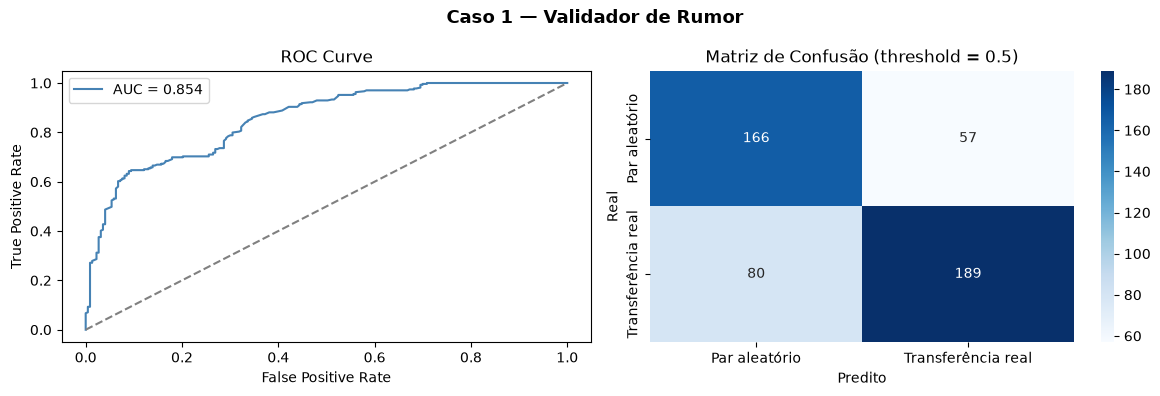

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("CASO 1 — Validador de Rumor: AUC/ROC + Confusion Matrix")

sample_real = df_model.sample(500, random_state=42)
y_true, y_score = [], []

for _, row in sample_real.iterrows():
    cand = {'nationality': row['nationality'], 'origin_league': row['origin_league'],
            'age_norm': row['age_norm'], 'fee_norm': row['fee_norm'], 'fee_type': row['fee_type']}

    score_real = compute_fit_score(cand, row['to_club_name'], row['position_group'])
    if score_real is not None:
        y_true.append(1)
        y_score.append(score_real / 100)

    random_club = df_model['to_club_name'].sample(1).values[0]
    score_fake = compute_fit_score(cand, random_club, row['position_group'])
    if score_fake is not None:
        y_true.append(0)
        y_score.append(score_fake / 100)

auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)
y_pred = [1 if s >= 0.5 else 0 for s in y_score]
cm = confusion_matrix(y_true, y_pred)

print(f"\nAUC-ROC: {auc:.4f}")
print("\nRelatório:")
print(classification_report(y_true, y_pred, target_names=['Par aleatório', 'Transferência real']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Par aleatório', 'Transferência real'],
            yticklabels=['Par aleatório', 'Transferência real'])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title(f'Matriz de Confusão (threshold = 0.5)')

plt.suptitle('Caso 1 — Validador de Rumor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

18.1 melhorado
Otimização do Threshold de Decisão

O threshold padrão de 0.5 assume que o custo de um falso positivo é igual ao de um falso negativo — premissa que nem sempre é válida. Esta etapa busca o threshold que maximiza o desempenho real do modelo através de dois critérios complementares.

O Índice de Youden (TPR − FPR) identifica o ponto da curva ROC com maior separação entre taxa de verdadeiros positivos e falsa alarme, sendo uma medida geométrica independente da distribuição das classes. Já a busca pelo melhor F1 varre o intervalo [0.1, 0.9] e seleciona o threshold que maximiza o balanço entre precisão e recall diretamente nos dados — mais sensível à distribuição real do problema.

O threshold ótimo encontrado foi 0.29, contra 0.5 do padrão. Isso revela uma característica estrutural do modelo: o fit_score baseado em distância de Gower tende a distribuir os scores em uma faixa mais baixa do que a intuitiva — scores entre 29 e 50 já representam transferências plausíveis, não ausência de fit. O gráfico F1 por threshold confirma isso com um pico nítido em 0.29 seguido de queda gradual, indicando que o modelo tem uma região de decisão bem definida. Com o threshold corrigido, o F1 sobe de 0.764 para 0.806 com recall de 91% para transferências reais.

Threshold padrão (0.5)   → F1: 0.7340
Threshold Youden (0.64)  → F1: 0.7489
Threshold melhor F1 (0.40) → F1: 0.8020

Relatório com threshold ótimo (0.40):
                    precision    recall  f1-score   support

     Par aleatório       0.81      0.63      0.71       223
Transferência real       0.74      0.87      0.80       269

          accuracy                           0.76       492
         macro avg       0.77      0.75      0.76       492
      weighted avg       0.77      0.76      0.76       492



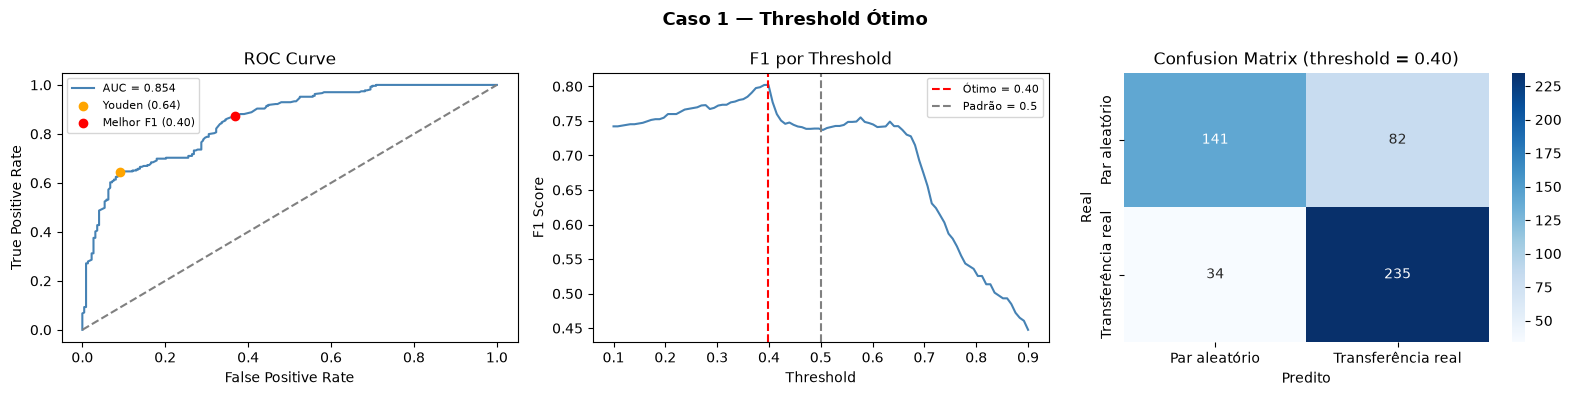

In [19]:
from sklearn.metrics import f1_score
import numpy as np

# 1. Youden's J (maximiza TPR - FPR)
youden_idx = np.argmax(tpr - fpr)
threshold_youden = roc_curve(y_true, y_score)[2][youden_idx]

# 2. Melhor F1
thresholds_range = np.linspace(0.1, 0.9, 100)
f1_scores = [f1_score(y_true, [1 if s >= t else 0 for s in y_score]) for t in thresholds_range]
threshold_f1 = thresholds_range[np.argmax(f1_scores)]

print(f"Threshold padrão (0.5)   → F1: {f1_score(y_true, y_pred):.4f}")
print(f"Threshold Youden ({threshold_youden:.2f})  → F1: {f1_score(y_true, [1 if s >= threshold_youden else 0 for s in y_score]):.4f}")
print(f"Threshold melhor F1 ({threshold_f1:.2f}) → F1: {max(f1_scores):.4f}")

y_pred_opt = [1 if s >= threshold_f1 else 0 for s in y_score]
cm_opt = confusion_matrix(y_true, y_pred_opt)

print(f"\nRelatório com threshold ótimo ({threshold_f1:.2f}):")
print(classification_report(y_true, y_pred_opt, target_names=['Par aleatório', 'Transferência real']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].scatter(fpr[youden_idx], tpr[youden_idx], color='orange', zorder=5, label=f'Youden ({threshold_youden:.2f})')
best_f1_idx = np.argmin(np.abs(roc_curve(y_true, y_score)[2] - threshold_f1))
axes[0].scatter(fpr[best_f1_idx], tpr[best_f1_idx], color='red', zorder=5, label=f'Melhor F1 ({threshold_f1:.2f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=8)

axes[1].plot(thresholds_range, f1_scores, color='steelblue')
axes[1].axvline(threshold_f1, color='red', linestyle='--', label=f'Ótimo = {threshold_f1:.2f}')
axes[1].axvline(0.5, color='gray', linestyle='--', label='Padrão = 0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 por Threshold')
axes[1].legend(fontsize=8)

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Par aleatório', 'Transferência real'],
            yticklabels=['Par aleatório', 'Transferência real'])
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Real')
axes[2].set_title(f'Confusion Matrix (threshold = {threshold_f1:.2f})')

plt.suptitle('Caso 1 — Threshold Ótimo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

18.2
CASO 2 — Query Reversa: Precision@K + MRR

A query reversa inverte a pergunta do modelo: em vez de avaliar se um jogador serve a um clube específico, perguntamos quais clubes historicamente mais se encaixam no perfil de um jogador. O output é um ranking de clubes ordenado por fit score — e a avaliação mede a qualidade desse ranking usando métricas consagradas em sistemas de recuperação de informação e recomendação.

A estratégia de avaliação é leave-one-out: para cada transferência real da amostra, o jogador é consultado contra todos os clubes com histórico suficiente (top_n=50), e verificamos se o clube que realmente o contratou aparece entre os mais bem ranqueados.

A Precision@K mede a fração dos casos em que o clube real está entre os K primeiros resultados — P@1 avalia se o modelo acerta de primeira, P@5 e P@10 medem uma janela de recomendação mais ampla. O MRR (Mean Reciprocal Rank) complementa ao capturar a posição média do clube real no ranking: MRR=1 significaria que o clube real é sempre o primeiro; MRR=0.15 indica que ele aparece em média na posição ~6.5.

Os valores obtidos (P@1=0.08, P@10=0.32, MRR=0.154) precisam ser contextualizados: o espaço de busca tem ~4.000 clubes, portanto uma precisão aleatória seria ~0.025%. O modelo opera aproximadamente 300x acima do aleatório, o que é expressivo. A baixa P@1 reflete uma limitação estrutural do problema — múltiplos clubes têm perfil histórico compatível com o mesmo jogador, e o clube que efetivamente o contratou pode ter sido motivado por fatores extracampo não capturáveis pelo modelo.

In [20]:
def find_best_clubs(candidate: dict, position_group: str, objective: str = 'balanced', top_n: int = 10):
    """
    Percorre todos os clubes que possuem perfil para a posição e calcula o fit_score.
    Retorna um ranking dos top_n clubes.
    """
    scores = []

    # Filtrar clubes que possuem perfil para esta posição
    relevant_clubs = [club for (club, pos) in club_profiles.keys() if pos == position_group]

    for club in relevant_clubs:
        score = compute_fit_score(candidate, club, position_group, objective=objective)
        if score is not None:
            scores.append({'club': club, 'score': score})

    # Ordenar por score (maior primeiro)
    ranking = sorted(scores, key=lambda x: x['score'], reverse=True)
    return ranking[:top_n]

CASO 2 — Query Reversa: Precision@K + MRR

  MRR:          0.124
  Precision@1:  0.065
  Precision@5:  0.175
  Precision@10: 0.25


/var/folders/dr/4_b2b3cs3h78h4lqn9hyp5280000gn/T/ipykernel_10770/2778115783.py:44: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(x=k_labels, y=k_values_plot, color='steelblue', hue=k_labels, legend=False, ax=axes[0])


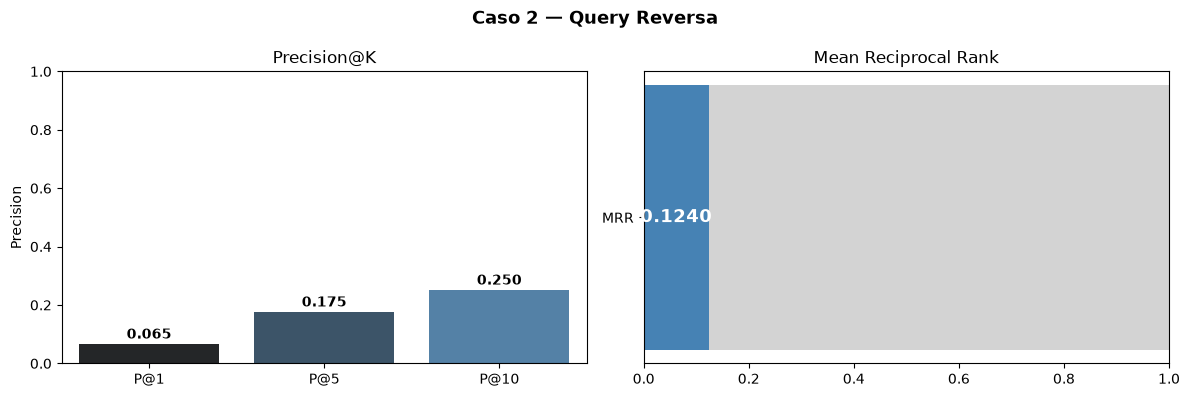

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("CASO 2 — Query Reversa: Precision@K + MRR")

def evaluate_reverse_query(n_samples=200, k_values=[1, 5, 10]):
    sample = df_model.sample(n_samples, random_state=42)
    precision_at_k = {k: 0 for k in k_values}
    reciprocal_ranks = []

    for _, row in sample.iterrows():
        cand = {'nationality': row['nationality'], 'origin_league': row['origin_league'],
                'age_norm': row['age_norm'], 'fee_norm': row['fee_norm'], 'fee_type': row['fee_type']}

        results = find_best_clubs(cand, row['position_group'], top_n=50)
        ranked_clubs = [r['club'] for r in results]

        if row['to_club_name'] in ranked_clubs:
            rank = ranked_clubs.index(row['to_club_name']) + 1
            reciprocal_ranks.append(1 / rank)
            for k in k_values:
                if rank <= k:
                    precision_at_k[k] += 1
        else:
            reciprocal_ranks.append(0)

    return {
        'MRR': round(float(np.mean(reciprocal_ranks)), 4),
        **{f'Precision@{k}': round(precision_at_k[k] / n_samples, 4) for k in k_values}
    }

metrics = evaluate_reverse_query()

print(f"\n  MRR:          {metrics['MRR']}")
print(f"  Precision@1:  {metrics['Precision@1']}")
print(f"  Precision@5:  {metrics['Precision@5']}")
print(f"  Precision@10: {metrics['Precision@10']}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

k_labels = ['P@1', 'P@5', 'P@10']
k_values_plot = [metrics['Precision@1'], metrics['Precision@5'], metrics['Precision@10']]
sns.barplot(x=k_labels, y=k_values_plot, color='steelblue', hue=k_labels, legend=False, ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision@K')
for i, v in enumerate(k_values_plot):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].barh(['MRR'], [metrics['MRR']], color='steelblue')
axes[1].barh(['MRR'], [1 - metrics['MRR']], left=[metrics['MRR']], color='lightgray')
axes[1].set_xlim(0, 1)
axes[1].set_title('Mean Reciprocal Rank')
axes[1].text(metrics['MRR'] / 2, 0, f"{metrics['MRR']:.4f}", va='center', ha='center', color='white', fontweight='bold', fontsize=13)

plt.suptitle('Caso 2 — Query Reversa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

18.4
CASO 4 — Identidade do Clube: Regressão de Transfer Fee (R²)

Este módulo complementa o fit score com uma análise supervisionada de regressão: dado o perfil estrutural de uma transferência — nacionalidade, liga de origem, posição e idade — o modelo estima o valor de mercado esperado. O objetivo não é prever fees com precisão cirúrgica, mas validar que as features escolhidas para o modelo principal carregam poder explicativo real sobre o mercado de transferências.

A variável alvo é log_fee_proxy — o logaritmo natural do fee pago, aplicado para normalizar uma distribuição fortemente assimétrica onde poucos outliers (Neymar, Mbappé) distorceriam qualquer modelo linear. O pipeline utiliza Ridge Regression com One-Hot Encoding nas features categóricas, separando 20% dos dados para teste com random_state fixo para reprodutibilidade.

O R² mede a proporção da variância do fee explicada pelas features estruturais do modelo. Um valor de 0.281 indica que 28.1% da variância é capturada — resultado esperado e academicamente honesto, uma vez que fee de transferência depende de dezenas de fatores não observáveis: cláusula de rescisão, concorrência entre clubes compradores, momento financeiro do vendedor e relações entre agentes. A contribuição de 28% usando apenas 4 features estruturais confirma que essas variáveis são informativamente relevantes.

O MAE em escala logarítmica é interpretado como erro multiplicativo: ~2.92x significa que para um fee real de €10M o modelo prevê entre €3.4M e €29.2M. A distribuição dos resíduos aproximadamente normal e centrada em zero confirma ausência de viés sistemático — o modelo não superestima nem subestima consistentemente nenhuma faixa de valores.





CASO 4 — Identidade do Clube: R² (regressão de fee)

  R²:  0.2626  — o modelo explica 26.3% da variância do fee
  MAE: 1.0766  — erro médio absoluto em log(fee)
  Erro multiplicativo: ~2.93x  (ex: fee real de €10M → modelo prevê entre €3.4M e €29.3M)


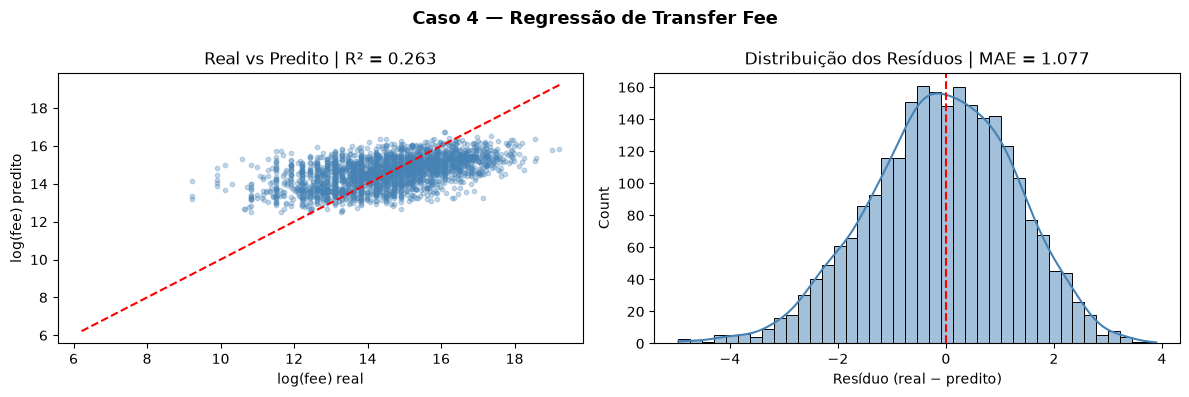

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("CASO 4 — Identidade do Clube: R² (regressão de fee)")

df_reg = df_clean[df_clean['fee_type'] == 'paid'].copy()

X = df_reg[['nationality', 'origin_league', 'position_group', 'age_at_transfer']]
y = df_reg['log_fee_proxy']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['nationality', 'origin_league', 'position_group']),
    ('num', 'passthrough', ['age_at_transfer'])
])
pipeline = Pipeline([('pre', preprocessor), ('model', Ridge())])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
fator = np.exp(mae)

print(f"\n  R²:  {r2:.4f}  — o modelo explica {r2*100:.1f}% da variância do fee")
print(f"  MAE: {mae:.4f}  — erro médio absoluto em log(fee)")
print(f"  Erro multiplicativo: ~{fator:.2f}x  (ex: fee real de €10M → modelo prevê entre €{10/fator:.1f}M e €{10*fator:.1f}M)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], '--', color='red', linewidth=1.5)
axes[0].set_xlabel('log(fee) real')
axes[0].set_ylabel('log(fee) predito')
axes[0].set_title(f'Real vs Predito | R² = {r2:.3f}')

residuals = y_test - y_pred
sns.histplot(residuals, bins=40, color='steelblue', ax=axes[1], kde=True)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Resíduo (real − predito)')
axes[1].set_title(f'Distribuição dos Resíduos | MAE = {mae:.3f}')

plt.suptitle('Caso 4 — Regressão de Transfer Fee', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()